In [44]:
import requests
import os
from datetime import datetime

# Diretório de destino (use r"" para evitar problemas com as barras invertidas no Windows)
DEST_DIR = r"C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao"
os.makedirs(DEST_DIR, exist_ok=True)

# Função para calcular o mês anterior
def get_previous_month(year, month):
    if month == 1:
        return year - 1, 12
    return year, month - 1

# Obtém a data atual e define os dois meses mais recentes
now = datetime.now()
current_year, current_month = now.year, now.month
months_to_download = [(current_year, current_month)]
months_to_download.append(get_previous_month(current_year, current_month))

# URLs bases para cada categoria
base_urls = {
    "fotovoltaica": "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_fotovoltaica_detail_tm/",
    "eolica": "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_eolica_detail_tm/"
}

# Padrões de nome dos arquivos para cada categoria
filename_patterns = {
    "fotovoltaica": "RESTRICAO_COFF_FOTOVOLTAICA_DETAIL_{year}_{month:02d}.parquet",
    "eolica": "RESTRICAO_COFF_EOLICA_DETAIL_{year}_{month:02d}.parquet"
}

# Para cada categoria e para os dois meses, monta a URL, faz o download e salva o arquivo (sobrescrevendo se necessário)
for category in ["fotovoltaica", "eolica"]:
    for year, month in months_to_download:
        file_name = filename_patterns[category].format(year=year, month=month)
        url = f"{base_urls[category]}{file_name}"
        print(f"Baixando [{category}] - {year}/{month:02d}: {url}")
        
        response = requests.get(url,verify=False)
        if response.status_code == 200:
            file_path = os.path.join(DEST_DIR, file_name)
            with open(file_path, "wb") as f:
                f.write(response.content)
            print(f"Arquivo salvo em: {file_path}")
        else:
            print(f"Falha ao baixar {url} (status code: {response.status_code})")


Baixando [fotovoltaica] - 2025/07: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_fotovoltaica_detail_tm/RESTRICAO_COFF_FOTOVOLTAICA_DETAIL_2025_07.parquet


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_FOTOVOLTAICA_DETAIL_2025_07.parquet
Baixando [fotovoltaica] - 2025/06: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_fotovoltaica_detail_tm/RESTRICAO_COFF_FOTOVOLTAICA_DETAIL_2025_06.parquet


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_FOTOVOLTAICA_DETAIL_2025_06.parquet
Baixando [eolica] - 2025/07: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_eolica_detail_tm/RESTRICAO_COFF_EOLICA_DETAIL_2025_07.parquet


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2025_07.parquet
Baixando [eolica] - 2025/06: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/restricao_coff_eolica_detail_tm/RESTRICAO_COFF_EOLICA_DETAIL_2025_06.parquet


C:\Users\joao.barbosa\AppData\Local\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo salvo em: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2025_06.parquet


In [45]:
import os
import glob
import pandas as pd

# Diretório onde estão os arquivos .parquet
dir_path = r"C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao"

# Lista todos os arquivos .parquet no diretório
file_pattern = os.path.join(dir_path, "*.parquet")
parquet_files = glob.glob(file_pattern)

if not parquet_files:
    print("Nenhum arquivo .parquet encontrado no diretório.")
else:
    # Lê cada arquivo e armazena os DataFrames em uma lista
    df_list = []
    for file in parquet_files:
        print(f"Lendo: {file}")
        df = pd.read_parquet(file)
        df_list.append(df)
    
    # Consolida todos os DataFrames em um único
    consolidated_df = pd.concat(df_list, ignore_index=True)
    
    # Salva o DataFrame consolidado em um novo arquivo .parquet
    #consolidated_file_path = os.path.join(dir_path, "consolidado.parquet")
    #consolidated_df.to_parquet(consolidated_file_path)
    #print(f"Arquivos consolidados salvos em: {consolidated_file_path}")


Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_01.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_02.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_03.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_04.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_05.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_06.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_07.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL_2024_08.parquet
Lendo: C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\RESTRICAO_COFF_EOLICA_DETAIL

In [50]:
import pandas as pd

# Caminhos dos arquivos
#consolidated_path = r"C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\geracao\consolidado.parquet"
cadastro_path = r"C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\cadastro\RELACIONAMENTO_USINA_EMPRESA.xlsx"

# Carrega os DataFrames
#consolidated_df = pd.read_parquet(consolidated_path)
cadastro_df = pd.read_excel(cadastro_path)

# Opcional: Converter a coluna "ceg" para 'category' para otimizar memória e performance
consolidated_df['ceg'] = consolidated_df['ceg'].astype('category')
cadastro_df['ceg'] = cadastro_df['ceg'].astype('category')



In [51]:
certificacao_path = r"C:\Users\joao.barbosa\Codigos\Geracao por usina\Data\cadastro\GERACAO_CERTIFICADA.xlsx"

In [52]:
certificacaop90_df = pd.read_excel(certificacao_path, sheet_name='P90')
certificacaop50_df = pd.read_excel(certificacao_path, sheet_name='P50')

In [53]:
def melt_cert(df_cert: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """Converte colunas 1-12 para linhas, devolve empresa / mes / valor."""
    return (
        df_cert
        .melt(id_vars=["Empresa"], var_name="mes", value_name=value_name)
        .assign(mes=lambda d: d["mes"].astype(int))     # garante int
    )

p50_long = melt_cert(certificacaop50_df.copy(), "p50_mwm")
p90_long = melt_cert(certificacaop90_df.copy(), "p90_mwm")


In [54]:
# Identifica os valores únicos de 'ceg' em cada DataFrame
cadastro_ceg = set(cadastro_df['ceg'].unique())
consolidated_ceg = set(consolidated_df['ceg'].unique())

# Determina quais 'ceg' do cadastro não foram encontrados no consolidated_df
missing_ceg = cadastro_ceg - consolidated_ceg

In [55]:
# Filtra o consolidated_df para manter apenas os registros cujo "ceg" está presente em cadastro_df
filtered_df = consolidated_df[consolidated_df['ceg'].isin(cadastro_df['ceg'])]

In [56]:
# Aqui usamos um left join para manter todas as linhas do consolidated_df, mas ajuste o parâmetro 'how' conforme a necessidade
merged_df = pd.merge(filtered_df, cadastro_df, on='ceg', how='left')

In [57]:
import pandas as pd

# Converter "din_instante" para datetime, se necessário
merged_df['din_instante'] = pd.to_datetime(merged_df['din_instante'])

# Cria uma nova coluna "mes_ano" extraída de "din_instante" (formato: AAAA-MM)
merged_df['mes_ano'] = merged_df['din_instante'].dt.strftime('%Y-%m')

# Agrupa o DataFrame pelas colunas de categoria e pela nova coluna "mes_ano"
# Somando os valores das colunas "val_geracaoestimada" e "val_geracaoverificada"
grouped_df = merged_df.groupby(['Complexo', 'SPE', 'empresa', 'mes_ano'], as_index=False)[['val_geracaoestimada', 'val_geracaoverificada']].mean()


In [62]:
grouped_df.to_excel(r"P:\João Marcos\dados_alta_freq\geração de energia\geracao_por_usina.xlsx")

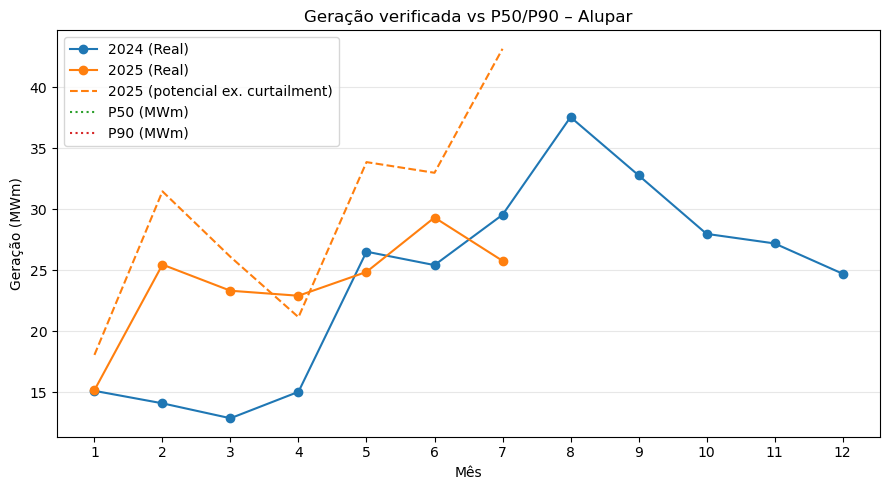

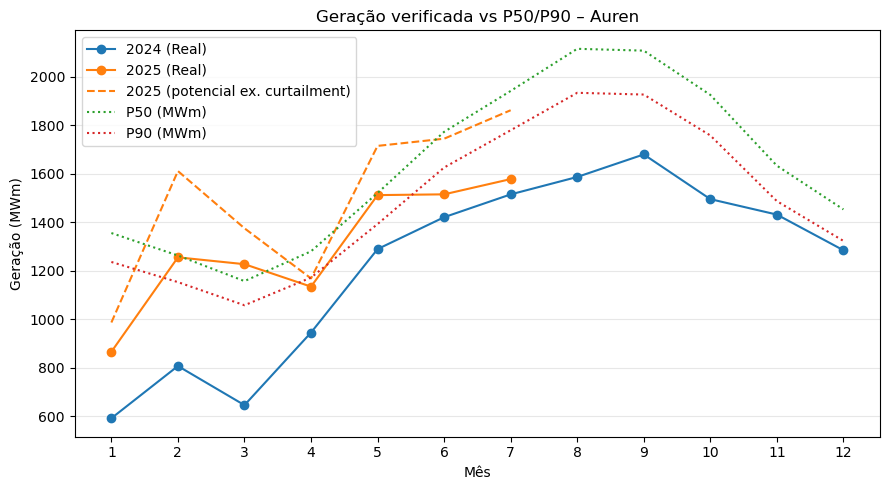

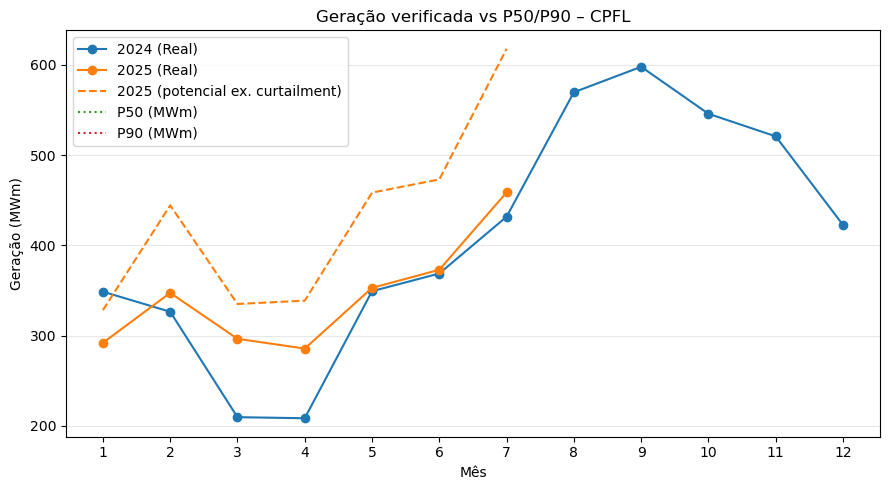

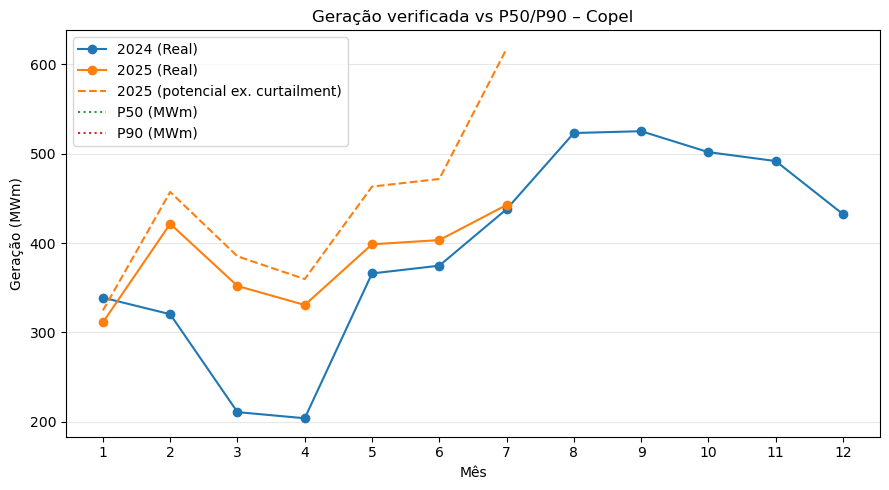

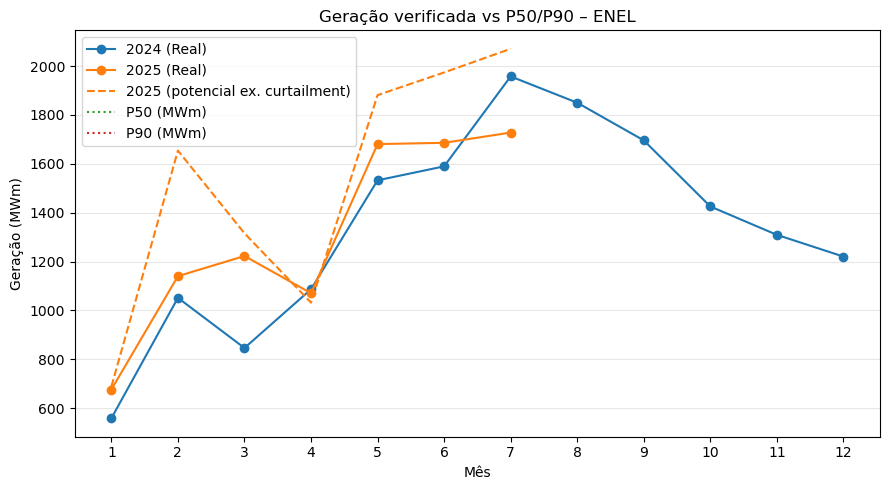

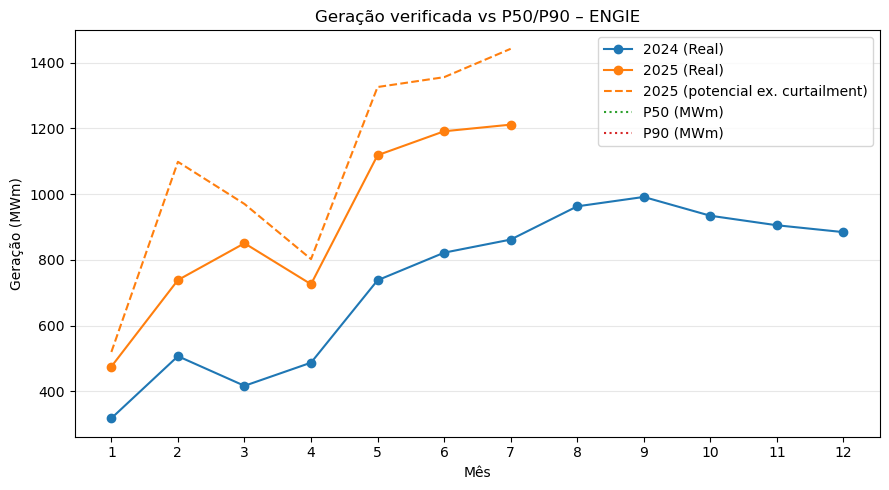

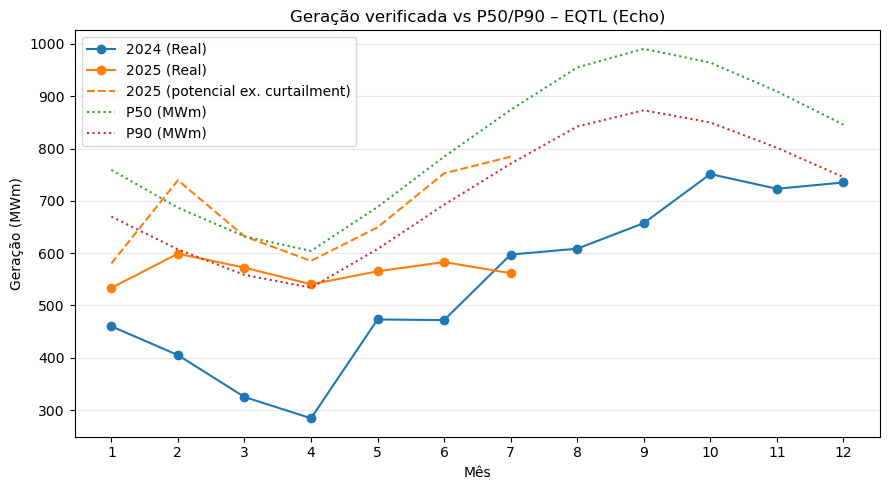

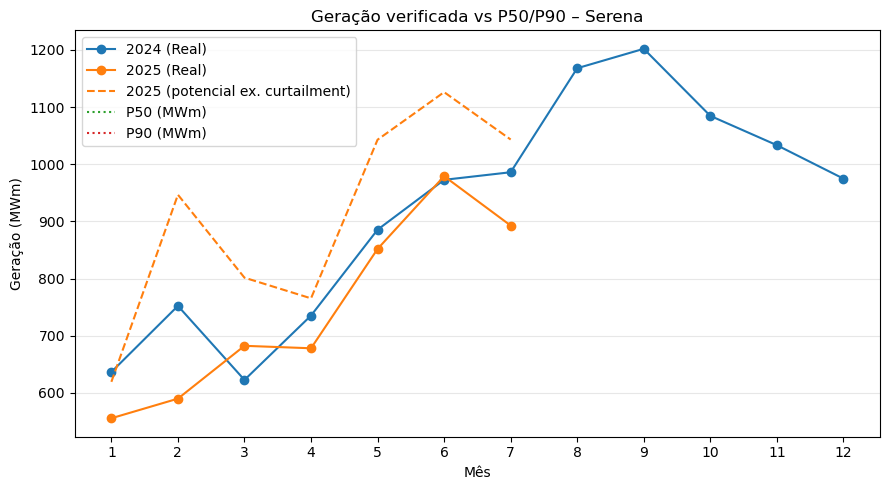

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# DADOS DE ENTRADA
#   • grouped_df  – geração verificada (MWm) linha a linha
#   • p50_long    – colunas: Empresa | mes | p50_mwm
#   • p90_long    – colunas: Empresa | mes | p90_mwm
# ------------------------------------------------------------------
grouped_df["mes_ano"] = pd.to_datetime(grouped_df["mes_ano"])

# ------------------------------------------------------------------
# 1)  Filtra 2024-2025  e adiciona colunas auxiliares
# ------------------------------------------------------------------
df = grouped_df[grouped_df["mes_ano"].dt.year.isin([2024, 2025])].copy()
df["ano"] = df["mes_ano"].dt.year
df["mes"] = df["mes_ano"].dt.month

# ------------------------------------------------------------------
# 2)  Loop por empresa → cria séries mensais → plota
# ------------------------------------------------------------------
for empresa, sub in df.groupby("empresa"):

    # ---------- REAL MWm (pivot) ----------
    real_tab = (
        sub.pivot_table(index="mes", columns="ano",
                        values="val_geracaoverificada",
                        aggfunc="sum")
           .reindex(range(1,13), fill_value=0.0)
    )
    vals_2024 = real_tab.get(2024, pd.Series(0, index=real_tab.index))
    vals_2025 = real_tab.get(2025, pd.Series(0, index=real_tab.index))

    # ---------- REAL MWm (pivot) ----------
    real_tab_estimado = (
        sub.pivot_table(index="mes", columns="ano",
                        values="val_geracaoestimada",
                        aggfunc="sum")
           .reindex(range(1,13), fill_value=0.0)
    )
    vals_2024_estimado = real_tab_estimado.get(2024, pd.Series(0, index=real_tab.index))
    vals_2025_estimado = real_tab_estimado.get(2025, pd.Series(0, index=real_tab.index))
    
    
    # ---------- P50 e P90 ----------
    p50_vals = (
        p50_long[p50_long["Empresa"] == empresa]
          .set_index("mes")["p50_mwm"]
          .reindex(range(1,13), fill_value=np.nan)
    )

    p90_vals = (
        p90_long[p90_long["Empresa"] == empresa]
          .set_index("mes")["p90_mwm"]
          .reindex(range(1,13), fill_value=np.nan)
    )

    # ---------- GRÁFICO ----------
    x = np.arange(1, 13)
    fig, ax = plt.subplots(figsize=(9,5))

    ax.plot(x, vals_2024, marker="o", linestyle="-",
            color="#1f77b4", label="2024 (Real)")
    ax.plot(x, vals_2025, marker="o", linestyle="-",
            color="#ff7f0e", label="2025 (Real)")
    ax.plot(x, vals_2025_estimado, marker="", linestyle="--",
            color="#ff7f0e", label="2025 (potencial ex. curtailment)")    
    ax.plot(x, p50_vals, marker="", linestyle=":",
            color="#2ca02c", label="P50 (MWm)")
    ax.plot(x, p90_vals, marker="", linestyle=":",
            color="#d62728", label="P90 (MWm)")

    ax.set_xlabel("Mês")
    ax.set_ylabel("Geração (MWm)")
    ax.set_title(f"Geração verificada vs P50/P90 – {empresa}")
    ax.set_xticks(x); ax.set_xticklabels(range(1,13))
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()           # ou plt.savefig(f"{empresa}_p50_p90.png")
